In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2

from models.linear_regression_pipelines import LinearRegressionPipelineWithPCA

In [ ]:
data = pd.read_csv(os.path.join(project_root, 'data', 'preprocessed_data.csv'))


In [ ]:
data.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,534,531363010,20,80.0,9605,7,6,2007,2007,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,803,906203120,20,90.0,14684,7,7,1990,1991,234.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,956,916176030,20,0.0,14375,6,6,1958,1958,541.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,460,528180130,120,48.0,6472,9,5,2008,2008,500.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,487,528290030,80,61.0,9734,7,5,2004,2004,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegressionPipelineWithPCA(n_components=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([216579.0787676 , 102387.65914646, 239327.51308502, 335956.17851782,
       214310.78488157, 298100.54639079, 236332.67711665, 169659.56412033,
       275508.34103511, 172063.00739656, 174825.27774137, 139688.68174816,
       215918.46311821, 157869.24209486, 211569.16853812, 177264.06846789,
       201261.56963233, 282499.24692669, 131015.42755033, 227627.31059185,
       230135.74070524, 222386.6947514 , 263435.43070836, 261350.27251714,
        83859.18937368, 174056.37372144, 158504.7321569 , 146420.21930027,
       231020.37495253, 154474.5821078 , 244875.68490213, 131587.50325984,
       184948.709981  , 330898.7258438 , 235555.84675913, 149383.29666168,
       261881.99853575, 178351.86876285, 243771.29301197, 109784.78194375,
       166546.28857619, 137807.46839728, 289402.44219794,  32571.26088022,
       122032.01799838, 281632.77765996,  81252.27846351, 320428.76906512,
       209658.58733711, 110789.45680226, 158265.57072531, 204434.46479552,
       121483.70703162, 1

In [ ]:
model.score(X_test, y_test)

0.77509586051359

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model.pipeline, X, y, cv=10)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.72991936 0.84288398 0.83888419 0.64070442 0.81101093 0.86266039
 0.80524833 0.73082725 0.8114659  0.82960441]
Average cross-validation score: 0.7903209153253588


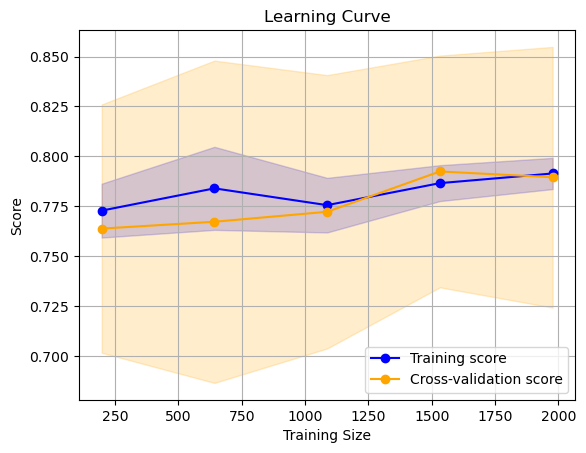

In [ ]:
from sklearn.model_selection import learning_curve

training_sizes, train_scores, test_scores = learning_curve(model.pipeline, X, y, cv=10)
plt.plot(training_sizes, train_scores.mean(axis=1), label='Training score', color='blue', marker='o')
plt.fill_between(training_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1), train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='blue')
plt.plot(training_sizes, test_scores.mean(axis=1), label='Cross-validation score', color='orange', marker='o')
plt.fill_between(training_sizes, test_scores.mean(axis=1) - test_scores.std(axis=1), test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.2, color='orange')
plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend()
plt.grid()

In [ ]:
output_dir = os.path.join(project_root, 'output', 'plots')
file_name = 'learning_curve.png'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

save_path = os.path.join(output_dir, file_name)
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='png')